In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
DATA_PATH = '/kaggle/input/competitions/playground-series-s6e6/train.csv'

# Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
 
print("=== Data shape（row, column）===")
print(df.shape)
 
print("\n=== First five data ===")
print(df.head())
 
print("\n=== Data type ===")
print(df.dtypes)

=== Data shape（row, column）===
(577347, 12)

=== First five data ===
   id       alpha      delta          u          g          r          i  \
0   0  147.734256  16.959273  25.472123  21.895559  20.357926  19.257113   
1   1  127.988677  32.346716  20.778509  19.087062  17.587208  17.226067   
2   2  179.792648  35.344843  21.035203  21.079128  21.171840  20.582629   
3   3  225.818295  48.569421  23.305056  21.050736  19.017754  18.365658   
4   4  141.836135  19.342852  21.703158  19.471680  18.234449  17.899447   

           z  redshift spectral_type galaxy_population   class  
0  18.621057  0.408982             M      Red_Sequence  GALAXY  
1  16.786433  0.157976             M      Red_Sequence  GALAXY  
2  20.557366  2.823770           O/B        Blue_Cloud     QSO  
3  17.914952  0.536099             M      Red_Sequence  GALAXY  
4  17.616185  0.555761             M      Red_Sequence  GALAXY  

=== Data type ===
id                     int64
alpha                float64
delta  

In [3]:
print("=== Missing data count ===")
print(df.isnull().sum())

missing_ratio = df.isnull().sum() / len(df) * 100
print("\n=== Missing ratio（%）===")
print(missing_ratio[missing_ratio > 0])

=== Missing data count ===
id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

=== Missing ratio（%）===
Series([], dtype: float64)


# Data Visualize

=== Each number ===
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

=== ratui（%）===
class
GALAXY    65.381824
QSO       20.289878
STAR      14.328298
Name: count, dtype: float64


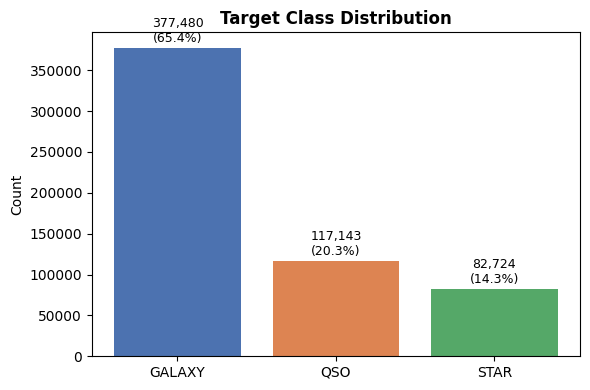

In [4]:
counts = df['class'].value_counts()
print("=== Each number ===")
print(counts)
print("\n=== ratui（%）===")
print(counts / len(df) * 100)
 
# plot image
palette = {'GALAXY': '#4C72B0', 'QSO': '#DD8452', 'STAR': '#55A868'}
 
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values,
              color=[palette[c] for c in counts.index])
ax.set_title('Target Class Distribution', fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3000,
            f'{val:,}\n({val / len(df) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Data Describe

In [5]:
num_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
 
print("=== Data  ===")
print(df[num_cols].describe().round(3))
 
# each class status
print("\n=== each class average ===")
print(df.groupby('class')[num_cols].mean().round(3))

=== Data  ===
            alpha       delta           u           g           r           i  \
count  577347.000  577347.000  577347.000  577347.000  577347.000  577347.000   
mean      181.617      21.835      22.442      21.007      19.963      19.379   
std        96.243      18.934       2.018       1.795       1.649       1.580   
min         0.012     -17.967      -0.139      13.535      12.579      11.963   
25%       132.161       2.474      20.977      19.865      18.821      18.307   
50%       188.681      21.484      22.570      21.468      20.431      19.632   
75%       231.830      36.988      23.869      22.293      21.164      20.608   
max       360.000      79.158      28.253      27.620      25.254      27.911   

                z    redshift  
count  577347.000  577347.000  
mean       19.041       0.723  
std         1.584       0.810  
min        11.683      -0.010  
25%        17.973       0.181  
50%        19.189       0.498  
75%        20.162       0.881  


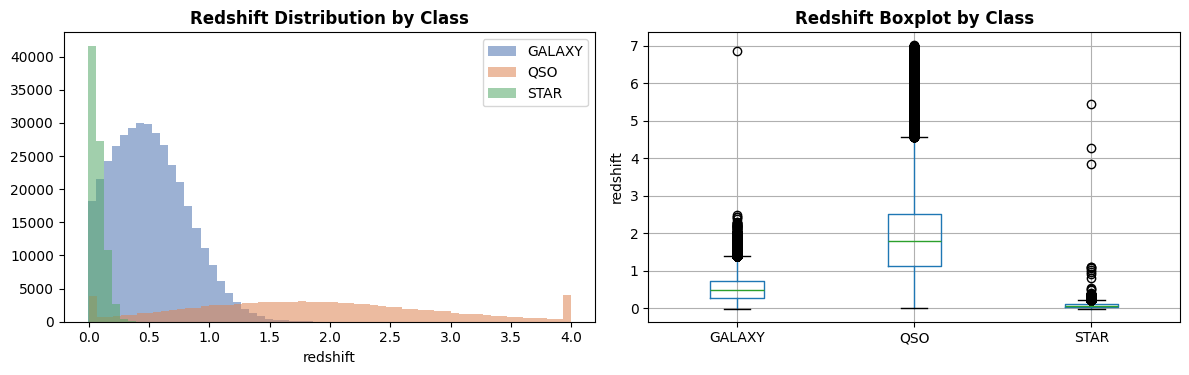

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, grp in df.groupby('class'):
    axes[0].hist(
        grp['redshift'].clip(-0.05, 4),   
        bins=60,
        alpha=0.55,                    
        label=cls,
        color=palette[cls]
    )
axes[0].set_title('Redshift Distribution by Class', fontweight='bold')
axes[0].set_xlabel('redshift')
axes[0].legend()
 
df.boxplot(column='redshift', by='class', ax=axes[1])
axes[1].set_title('Redshift Boxplot by Class', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('redshift')
plt.suptitle('') 
plt.tight_layout()
plt.show()

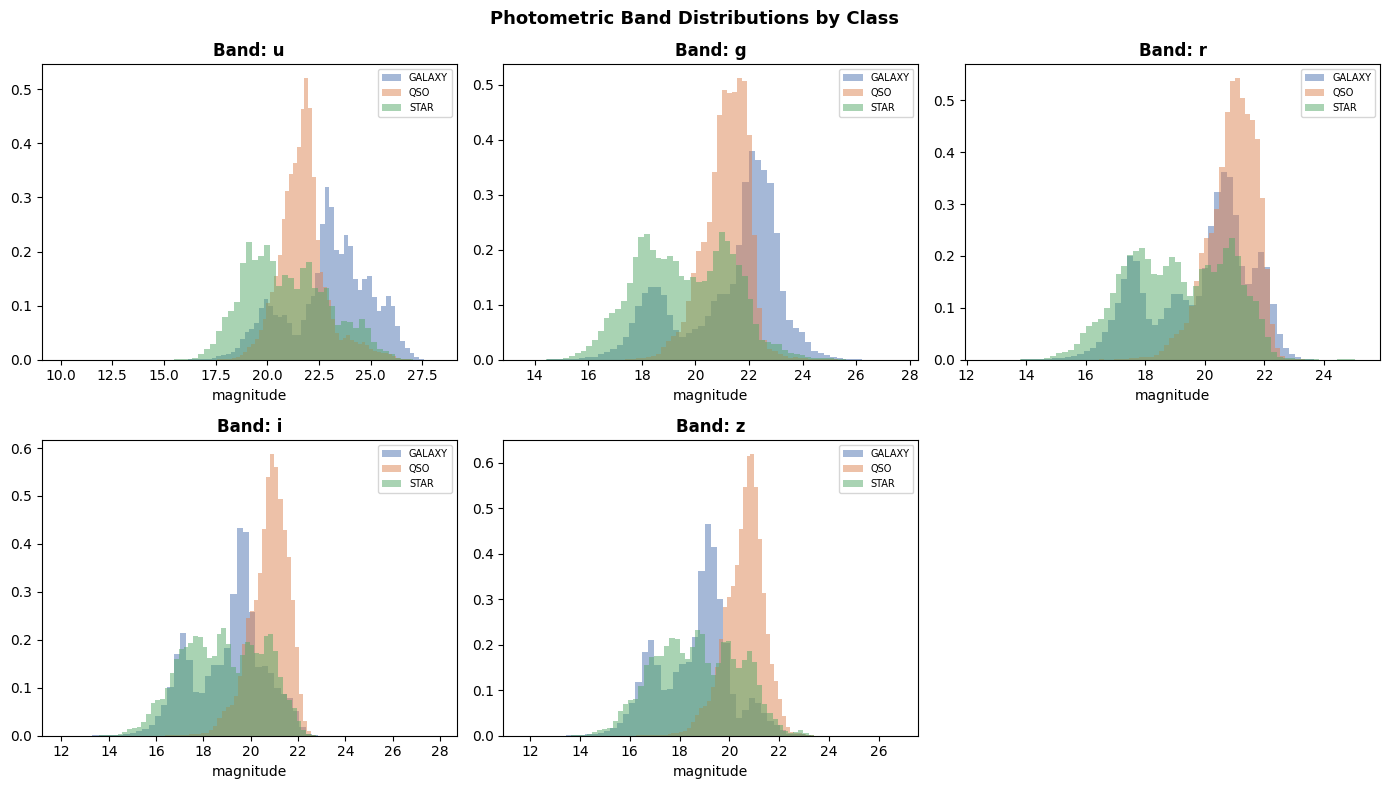

In [7]:
bands = ['u', 'g', 'r', 'i', 'z']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()   
 
for idx, col in enumerate(bands):
    ax = axes[idx]
    for cls, grp in df.groupby('class'):
        ax.hist(
            grp[col].clip(10, 30),   # remove data outside 10~30
            bins=60,
            alpha=0.5,
            label=cls,
            color=palette[cls],
            density=True             # normalize
        )
    ax.set_title(f'Band: {col}', fontweight='bold')
    ax.set_xlabel('magnitude')
    ax.legend(fontsize=7)
 
axes[-1].axis('off') 
fig.suptitle('Photometric Band Distributions by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
cat_cols = ['spectral_type', 'galaxy_population']
 
for col in cat_cols:
    print(f"\n=== {col} distribution ===")
    print(df[col].value_counts())
 
    print(f"\n=== {col} vs class（%）===")
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    print(ct.round(1))


=== spectral_type distribution ===
spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

=== spectral_type vs class（%）===
class          GALAXY   QSO  STAR
spectral_type                    
A/F              19.8  50.4  29.8
G/K              56.8  19.3  24.0
M                95.0   1.3   3.8
O/B               8.3  71.1  20.6

=== galaxy_population distribution ===
galaxy_population
Red_Sequence    319565
Blue_Cloud      257782
Name: count, dtype: int64

=== galaxy_population vs class（%）===
class              GALAXY   QSO  STAR
galaxy_population                    
Blue_Cloud           34.5  42.0  23.5
Red_Sequence         90.3   2.8   6.9


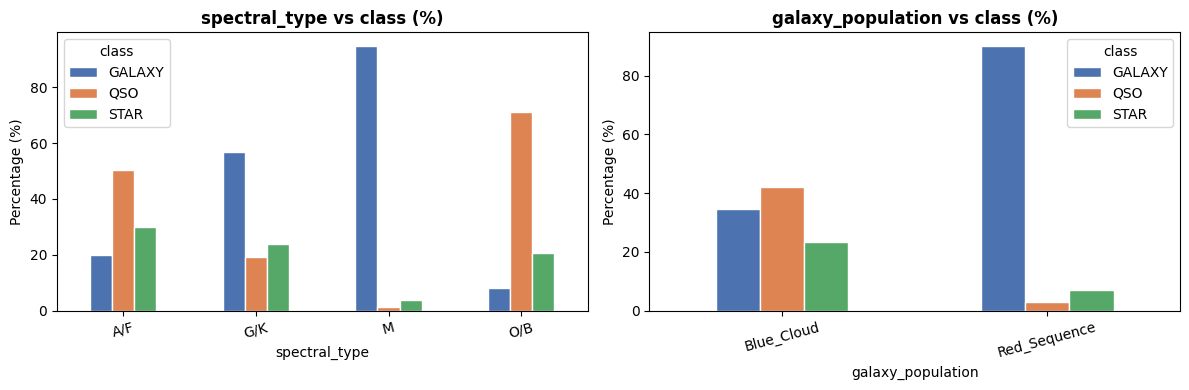

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['class'], normalize='index') * 100
    ct.plot(
        kind='bar',                              # bar chart
        ax=ax,
        color=[palette[c] for c in ct.columns],
        edgecolor='white'
    )
    ax.set_title(f'{col} vs class (%)', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='class')
 
plt.tight_layout()
plt.show()

# Correlation Map

=== correlation matrix ===
          alpha  delta     u     g     r     i     z  redshift
alpha      1.00   0.14 -0.02 -0.04 -0.04 -0.03 -0.02      0.01
delta      0.14   1.00 -0.03 -0.01 -0.00  0.00  0.00      0.05
u         -0.02  -0.03  1.00  0.83  0.66  0.52  0.44      0.08
g         -0.04  -0.01  0.83  1.00  0.91  0.81  0.73      0.24
r         -0.04  -0.00  0.66  0.91  1.00  0.95  0.91      0.39
i         -0.03   0.00  0.52  0.81  0.95  1.00  0.97      0.47
z         -0.02   0.00  0.44  0.73  0.91  0.97  1.00      0.48
redshift   0.01   0.05  0.08  0.24  0.39  0.47  0.48      1.00


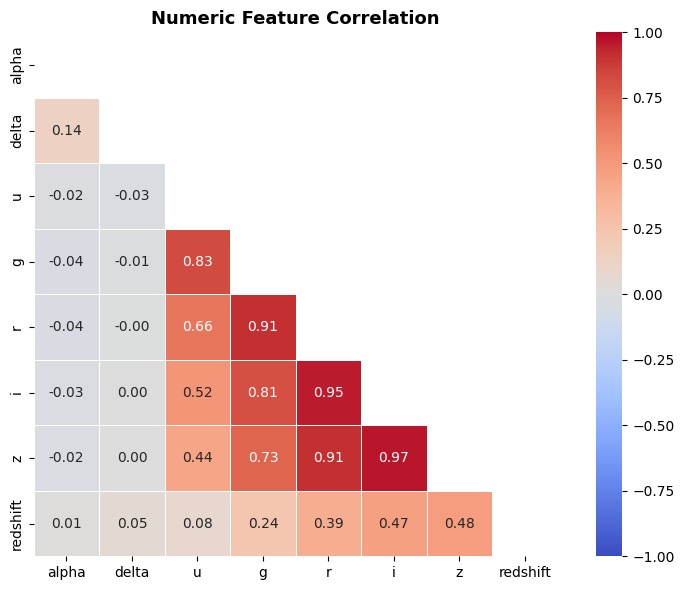

In [10]:
corr = df[num_cols].corr()
print("=== correlation matrix ===")
print(corr.round(2))
 
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',      
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Numeric Feature Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter Plot

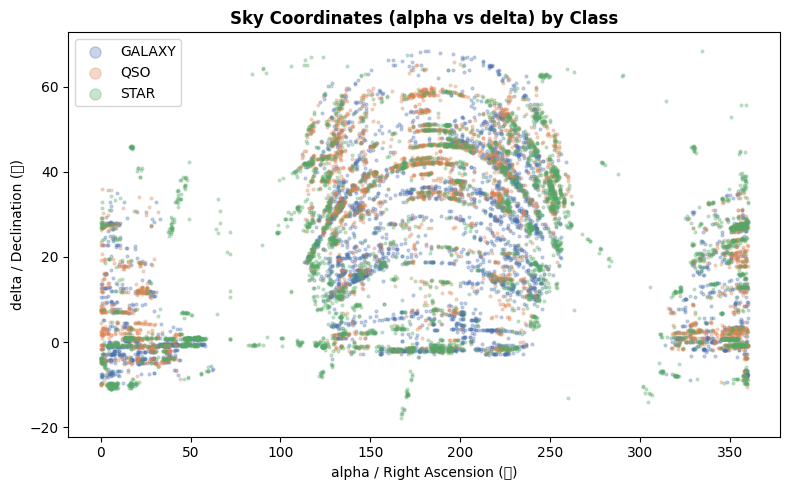

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
 
for cls, grp in df.groupby('class'):
    sample = grp.sample(min(4000, len(grp)), random_state=42) 
    ax.scatter(
        sample['alpha'], sample['delta'],
        s=4,
        alpha=0.3,
        label=cls,
        color=palette[cls]
    )
 
ax.set_title('Sky Coordinates (alpha vs delta) by Class', fontweight='bold')
ax.set_xlabel('alpha / Right Ascension (度)')
ax.set_ylabel('delta / Declination (度)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

In [12]:
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']
 
color_cols = ['u_g', 'g_r', 'r_i', 'i_z']
 
print("=== each class color mean ===")
print(df.groupby('class')[color_cols].mean().round(3))

=== each class color mean ===
          u_g    g_r    r_i    i_z
class                             
GALAXY  1.719  1.410  0.792  0.438
QSO     0.564  0.242  0.151  0.165
STAR    1.369  0.515  0.245  0.123


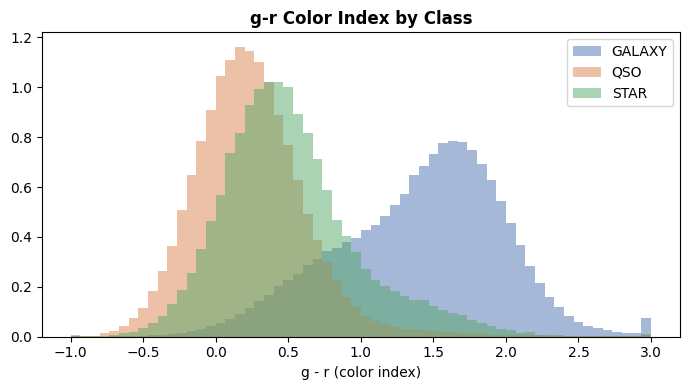

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
for cls, grp in df.groupby('class'):
    ax.hist(grp['g_r'].clip(-1, 3), bins=60, alpha=0.5,
            label=cls, color=palette[cls], density=True)
ax.set_title('g-r Color Index by Class', fontweight='bold')
ax.set_xlabel('g - r (color index)')
ax.legend()
plt.tight_layout()
plt.show()